1. python => mysql 연결
2. CRUD 함수 => langchain @tool 변환
3. LLM Tool Calling
4. LangGraph state, node, edge, router
5. updata, delecte => HITL 적용
6. 역활에 따라 MySQL, RAG를 적용
7. Hybrid Agent 

1. 환경 설치

In [2]:
# %pip install mysql-connector-python

2. 라이브러리 연결

In [1]:
import os
import json
import mysql.connector

from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

from langgraph.graph import START, END, StateGraph

import warnings
warnings.filterwarnings('ignore')

In [2]:
load_dotenv()

True

3. MySQL 연결

In [3]:
DB_CONFIG ={
    'host': os.getenv("MYSQL_HOST", 'localhost'),
    'user': os.getenv("MYSQL_USER", 'root'),
    'password': os.getenv("MYSQL_PASSWORD", '123456'),
    'database': os.getenv("MYSQL_DATABASE", 'mysqldb'),
}

def get_connection():
    """
    MYSQL 연결 객체(connection)을 생성하는 함수입니다.
    
    매번 CRUD 함수를 실행할때 새로운 DB 연결을 만들어 반환합니다.
    """

    return mysql.connector.Connect(
        **DB_CONFIG
    )
    

4. 학생(students) 테이블 생성

In [4]:
# MySQL 서버 연결
conn = get_connection()

# sql 명령어 실행을 위한 cursor 생성
cursor = conn.cursor()

sql = '''
create table if not exists students(
    id int auto_increment primary key,
    name varchar(30) not null,
    age int,
    course varchar(50)
)
'''

cursor.execute(sql)  # SQL 실행
conn.commit()  # DB 적용

cursor.close()
conn.close()


============================================================

3. MySQL CRUD 함수 생성

In [5]:
# caeate
def create_student(name:str, age:int, course:str):
    """
    새로운 학생 정보를 MySQL에 추가하는 함수입니다.
    """

    # db 연결
    conn = get_connection()
    cursor = conn.cursor()

    # 데이터 추가
    sql ="""
    insert into students
    (name, age, course)
    values (%s, %s, %s)
    """
    cursor.execute(sql, (name, age, course))
    conn.commit()

    # 추가된 학생의 ID 반환: 마지막에 등록된 자동 생성 id 반환
    student_id = cursor.lastrowid

    # db 연결 종료
    cursor.close()
    conn.close()

    return student_id

In [6]:
# 테스트
student_id = create_student('이순신', 48, 'LangChain')
print(student_id)

1


In [7]:
# read = 전체 조회
def read_students():
    """
    students 테이블에서 전체 학생 정보를 조회하는 함수입니다.
    """
    
    # db 연결
    conn = get_connection()
    cursor = conn.cursor(dictionary=True) # dict 형태로 데이터 반환

    sql = """
    select id, name, age, course 
    from students
    order by id
    """ 

    cursor.execute(sql)

    # fetchall() => 조회된 모든 행을 리스트로 반환
    rows = cursor.fetchall()

    cursor.close()
    conn.close()

    return rows
    

In [8]:
# read = 이름을 이용한 조회
def read_students_by_name(name:str):
    """
    students 테이블에서 name을 이용해 학생 정보를 조회하는 함수입니다.
    """
    
    # db 연결
    conn = get_connection()
    cursor = conn.cursor(dictionary=True) # dict 형태로 데이터 반환

    sql = """
    select id, name, age, course 
    from students
    where name = %s
    """ 

    cursor.execute(sql, (name,))

    # fetchall() => 조회된 모든 행을 리스트로 반환
    rows = cursor.fetchall()

    cursor.close()
    conn.close()

    return rows

In [9]:
# 테스트
rows = read_students_by_name('홍길동')
for row in rows:
    print(row)

In [10]:
# update: 이름을 기준으로 과목 수정
def update_studect_course(name:str, course:str):
    """
    students 테이블에서 name을 기준으로 과목 수정하는 함수입니다.
    """
    
    # db 연결
    conn = get_connection()
    cursor = conn.cursor() 

    sql = """
    update students
    set course = %s
    where name = %s
    """ 

    cursor.execute(sql, (course,name,))
    conn.commit()

    count = cursor.rowcount # db에서 실제로 영향을 받은 행의 개수

    cursor.close()
    conn.close()

    return count

In [11]:
update_course = update_studect_course("홍길동", "LangGraph")
print(f'수정된 데이터: {update_course}')

수정된 데이터: 0


In [12]:
# Delete
def delete_student_by_name(name:str):
    """
    학생 이름을 기준으로 학생 정보를 삭제하는 함수입니다.

    주의:
    실제 DB가 삭제되는 함수
    """
    # db 연결
    conn = get_connection()
    cursor = conn.cursor() 

    sql = """
    delete from students
    where name = %s
    """ 

    cursor.execute(sql, (name,))
    conn.commit()

    count =cursor._rowcount

    cursor.close()
    conn.close()

    return count


In [13]:
# 테스트
cnt = delete_student_by_name('홍길동')
print(f'삭제된 레코드: {cnt}')

삭제된 레코드: -1


=======================================================

4. CRUD 함수를 LangChain Tool로 변환

- 조회 Tool

In [14]:
@tool
def search_student(name:str) -> str:
    """
    학생의 이름을 이용해 MySQL에서 학생 정보를 조회합니다.
    """

    student = read_students_by_name(name)

    if student is None:
        return {
            f'{name} 학생을 찾을 수 없습니다.'
        }

    return json.dumps(
        student,
        ensure_ascii=False  # 실제 한글로 출력, True => \\uXXXX
        )
    

- 추가 Tool

In [15]:
@tool
def add_student(name:str, age:int, course:str) -> str:
    '''
    새로운 학생을 MySQL에 추가합니다.
    '''

    student_id = create_student(
        name=name,
        age=age,
        course=course
    )

    return f'학생 추가 완료 => id:{student_id}, 이름: {name}'

- 수정 Tool

In [16]:
@tool
def change_student_course(name:str, course:str) -> str:
    '''
    학생 이름을 기준으로 과목을 수정합니다.
    '''
    cnt = update_studect_course(
        name=name,
        course=course,
    )

    if cnt == 0:
        return f'{name} 학생을 찾을 수가 없습니다.'

    return f'{name} 학생에 대한 수강과목을 {course}로 변경하였습니다.'

- 삭제 Tool

In [17]:
@tool
def remove_student(name:str) -> str:
    """
    학생 정보를 MySQL에서 삭제합니다.
    """
    cnt = delete_student_by_name(name)

    if cnt == 0:
        return f'{name} 학생을 찾을 수 없습니다.'

    return f'{name} 학생 정보를 삭제하였습니다.'

In [18]:
tools=[search_student, 
       add_student, 
       change_student_course, 
       remove_student]

In [19]:
for t in tools:
    print(t.name,"-", t.description)

search_student - 학생의 이름을 이용해 MySQL에서 학생 정보를 조회합니다.
add_student - 새로운 학생을 MySQL에 추가합니다.
change_student_course - 학생 이름을 기준으로 과목을 수정합니다.
remove_student - 학생 정보를 MySQL에서 삭제합니다.


==================================================

6. LangChain ToolCalling

In [36]:
llm = ChatOpenAI(model="gpt-4o")

llm_with_tools = llm.bind_tools(tools)

7. LangGraph MySQL CRUD Agent 

- State 정의

In [37]:
class StudentAgentState(TypedDict,total=False):
    question: str
    action: str            # CRUD 종류 판단
    name: str
    age: int
    course: str
    db_result: str         # DB 실행 결과
    final_answer: str      # 최종 사용자 답변

- 요청 분석

In [38]:
class CRUDRequest(BaseModel):
    action: Literal['create', 'read', 'update', 'delete'] = Field(
        description='사용자가 원하는 CRUD 작업'
    )
    name: str = Field(default="", description="학생 이름")
    age: int = Field(default=0, description="학생 나이")
    course: str = Field(default="", description='수강과목')

llm_request = llm.with_structured_output(CRUDRequest)

- 요청 분석 노드

In [39]:
def analyze_request(state:StudentAgentState) -> StudentAgentState:
    """
    사용자 질문을 분석해 CRUD 작업 종류와 필요한 값을 추출하는 Node입니다.
    """

    print('=== 요청 분석 ===')
    # 사용자 질문을 LLM에게 전달
    result = llm_request.invoke(state['question'])

    return {
        "action": result.action,
        'name': result.name,
        'age': result.age,
        'course': result.course

    }

- Router

In [40]:
def router_action(state:StudentAgentState) -> Literal['create', 'read', 'update', 'delete']:
    """
    analyze_request()에서 결정한 action 값을 기준으로 다음에 실행할 노드 이름 반환
    """
    return state['action']

- CRUD nodes

In [41]:
def create_node(state:StudentAgentState) -> StudentAgentState:
    """
    create tool 실행 Node
    """
    print('--- Create Node ---')

    result = add_student.invoke(
        {
            "name": state['name'],
            "age": state['age'],
            "course": state['course'],
        }
    )

    return {"db_result": result}

In [42]:
def read_node(state:StudentAgentState) -> StudentAgentState:
    """
    Read tool 실행 Node
    """
    print('--- Read Node ---')

    result = search_student.invoke(
        {
            "name": state['name'],
        }
    )

    return {"db_result": result}

In [43]:
def update_node(state:StudentAgentState) -> StudentAgentState:
    """
    update tool 실행 Node
    """
    print('--- Update Node ---')

    result = change_student_course.invoke(
        {
            "name": state['name'],
            "course": state['course'],
        }
    )

    return {"db_result": result}

In [44]:
def delete_node(state:StudentAgentState) -> StudentAgentState:
    """
    delete tool 실행 Node
    """
    print('--- Delete Node ---')

    result = remove_student.invoke(
        {
            "name": state['name'],
        }
    )

    return {"db_result": result}

In [45]:
def generate_answer(state:StudentAgentState) -> StudentAgentState:
    return{
        'final_answer': f'요청 처리 결과: {state.get("db_result", "")}'
        }

==== 일반 =========================================

- Graph 구성

In [46]:
workflow = StateGraph(StudentAgentState)
workflow.add_node("analyze", analyze_request)
workflow.add_node("create", create_node)
workflow.add_node("read", read_node)
workflow.add_node("update", update_node)
workflow.add_node("delete", delete_node)
workflow.add_node("answer", generate_answer)

workflow.add_edge(START, "analyze")
workflow.add_conditional_edges(
    "analyze",
    router_action,
    {
        'create': 'create', 
        'read': 'read', 
        'update': 'update', 
        'delete': 'delete',
     }
)

# 모든 CRUD Node의 결과는 answer로 연결
for node in ['create', 'read', 'update', 'delete']:
    workflow.add_edge(node, "answer")

workflow.add_edge("answer", END)

student_agent = workflow.compile()

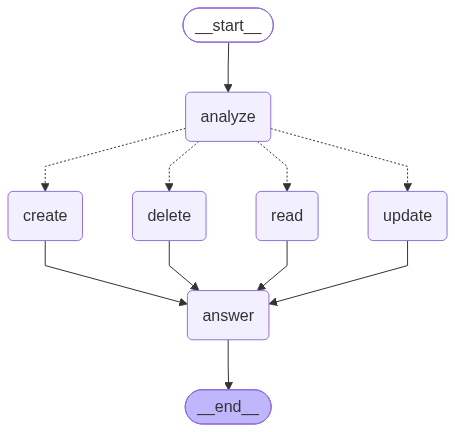

In [47]:
from IPython.display import Image, display

display(Image(student_agent.get_graph().draw_mermaid_png()))

In [48]:
# 테스트
q = '이순신 학생의 정보를 조회해 주세요'
result = student_agent.invoke(
    {
        'question': q
    }
)

print(result.get('final_answer'))

=== 요청 분석 ===
--- Read Node ---
요청 처리 결과: [{"id": 1, "name": "이순신", "age": 48, "course": "LangChain"}]


In [49]:
q = '서정동 학생을 추가해주세요, 나이는 50세이고 수업은 RAG를 신청했습니다.'
result = student_agent.invoke(
    {
        'question': q
    }
)

print(result.get('final_answer'))

=== 요청 분석 ===
--- Create Node ---
요청 처리 결과: 학생 추가 완료 => id:2, 이름: 서정동


===== HITL =========================================

### HITL용 MemorySaver 및 Graph 생성

```text
사용자 요청
   ↓
analyze
   ↓
UPDATE / DELETE
   ↓
Graph 일시중단
   ↓
사용자 승인
 ├─ 승인 → 실제 DB 변경
 └─ 거절 → 실행하지 않음
```

In [50]:
# HITL용 Checkpointer

from langgraph.checkpoint.memory import MemorySaver

hitl_builder = StateGraph(StudentAgentState)

# Node 등록
hitl_builder.add_node("analyze", analyze_request)
hitl_builder.add_node("create", create_node)
hitl_builder.add_node("read", read_node)
hitl_builder.add_node("update", update_node)
hitl_builder.add_node("delete", delete_node)
hitl_builder.add_node("answer", generate_answer)

# START → analyze
hitl_builder.add_edge(START,"analyze")

# CRUD 조건부 분기
hitl_builder.add_conditional_edges(
    "analyze",
    router_action,
    {
        "create": "create",
        "read": "read",
        "update": "update",
        "delete": "delete",
    }
)


# CRUD → answer
for node in ["create", "read", "update", "delete",]:
    hitl_builder.add_edge(node, "answer")

# answer → END
hitl_builder.add_edge( "answer", END)



In [53]:
# MemorySaver 생성
hitl_memory = MemorySaver()

# interrupt_before
hitl_agent = hitl_builder.compile(
    checkpointer=hitl_memory,
    interrupt_before=["update","delete",],
)


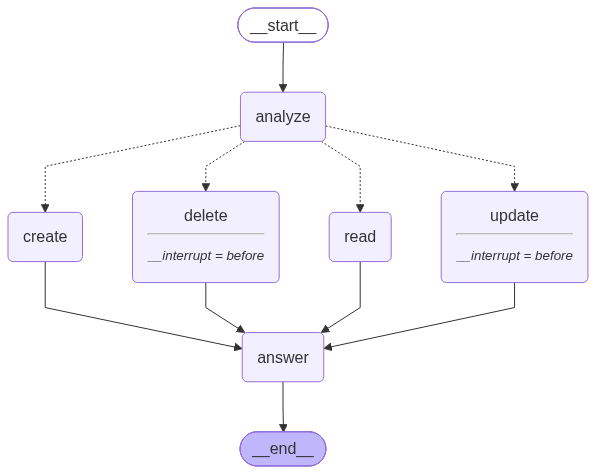

In [ ]:
from IPython.display import Image, display

display(Image(hitl_agent.get_graph().draw_mermaid_png()))

#### HITL UPDATE 요청 실행

In [55]:
# thread_id는 하나의 실행 세션을 구분
hitl_config = {"configurable": {"thread_id": "mysql-hitl-001"}}

# UPDATE 요청
result = hitl_agent.invoke(
    {
        "question":
        "서정동 학생의 수강과목을 RAG 심화로 변경해주세요."
    },
    config=hitl_config,
)

print("[현재 State]")
print(result)

=== 요청 분석 ===
[현재 State]
{'question': '서정동 학생의 수강과목을 RAG 심화로 변경해주세요.', 'action': 'update', 'name': '서정동', 'age': 0, 'course': 'RAG 심화'}


In [56]:
# 현재 Graph가 어느 Node 앞에서 멈췄는지 확인
snapshot = hitl_agent.get_state(hitl_config)

print("\n다음 실행 Node:", snapshot.next)


다음 실행 Node: ('update',)


#### 승인 후 UPDATE 계속 실행

In [57]:
user_approval = input("수정 작업을 실행하시겠습니까? (yes/no): ").strip().lower()

if user_approval in ["yes", "y", "예",]:
    # None을 전달하면 중단된 Graph를 이어서 실행
    final_result = hitl_agent.invoke(None, config=hitl_config,)
    print(final_result.get("final_answer"))

else:
    print("사용자가 수정 작업을 취소했습니다.")

--- Update Node ---
요청 처리 결과: 서정동 학생에 대한 수강과목을 RAG 심화로 변경하였습니다.


- 승인후 삭제

In [58]:
# Delete 요청
result = hitl_agent.invoke(
    {
        "question":
        "서정동 학생에 대한 데이터를 삭제해주세요."
    },
    config=hitl_config,
)

user_approval = input("수정 작업을 실행하시겠습니까? (yes/no): ").strip().lower()

if user_approval in ["yes", "y", "예",]:
    # None을 전달하면 중단된 Graph를 이어서 실행
    final_result = hitl_agent.invoke(None, config=hitl_config,)
    print(final_result.get("final_answer"))

else:
    print("사용자가 삭제 작업을 취소했습니다.")

=== 요청 분석 ===
--- Delete Node ---
요청 처리 결과: 서정동 학생 정보를 삭제하였습니다.


### 7. RAG + MySQL Hybrid Agent

```text
                         사용자
                            ↓
                      LangGraph Router
                            ↓
             ┌──────────────┴──────────────┐
             ↓                             ↓
           RAG                           MySQL
             ↓                             ↓
      학사 규정 / PDF              학생 / 회원 / 주문
             ↓                             ↓
             └──────────────┬──────────────┘
                            ↓
                           LLM
                            ↓
                        최종 답변

- LangChain Tool: Python/MySQL 기능을 LLM이 사용할 수 있게 만듦
- LangGraph Router: 질문 종류에 따라 실행 경로 결정
- HITL: DB 변경 전에 사람의 승인을 받음
- RAG + MySQL Hybrid: 비정형 문서와 정형 DB를 함께 사용

- 수업용 규정 문서 생성 및 Vector DB 생성

In [62]:
from typing import List

from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_openai import OpenAIEmbeddings

In [63]:
policy_documents = [

    Document(
        page_content=(
            "수강신청 변경 기간은 "
            "학기 시작 후 7일 이내입니다."
        ),
        metadata={
            "source": "학사규정",
            "category": "수강신청",
        }
    ),

    Document(
        page_content=(
            "출석률이 70% 미만인 경우 "
            "해당 과목에서 F 학점을 받을 수 있습니다."
        ),
        metadata={
            "source": "학사규정",
            "category": "출석",
        }
    ),

    Document(
        page_content=(
            "학생은 한 학기에 최대 21학점까지 "
            "수강 신청할 수 있습니다."
        ),
        metadata={
            "source": "학사규정",
            "category": "학점",
        }
    ),

]

In [64]:
# 벡터 DB 생성
embeddings = OpenAIEmbeddings(model = 'text-embedding-3-large')

policy_db = Chroma.from_documents(
  documents = policy_documents,
  embedding = embeddings,
  collection_name = 'school_policy'
)

policy_retriever = policy_db.as_retriever(
  search_kwargs={"k" : 2}
)

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [66]:
def search_policy(question:str) -> str:
  docs = policy_retriever.invoke(question)

  if not docs:
    return ('관련 규정을 찾을 수 없습니다')

  contents = []
  for doc in docs:
    contents.append(
      f'[출처 : {doc.metadata.get("source", "")}]\n'
      f'{doc.page_content}'
    )

  return "\n\n".join(contents)

In [67]:
class HybridState(TypedDict, total = False):
  question: str
  datasource: str
  context: str    # 검색 결과 (RAG 또는 MySQL의 검색 결과)
  final_answer: str

In [68]:
class HybridRoute(BaseModel):
  datasource: Literal['rag', 'mysql'] = Field(
    description='학사 규정/정책/일반 규칙은 rag ' \
    '특정 학생에 대한 이름/나이/수강과목 등 학생 DB정보에 대한 질문은 mysql')

hybrid_router = llm.with_structured_output(HybridRoute)

- 질문 분석에 따른 분기 노드

In [70]:
def analyze_hybrid_question(state: HybridState) -> HybridState:
  """
  사용자 질문을 분석하여 RAG 또는 MySQL 중 하나를 사용한 데이터를 선택합니다.
  """

  print('--- hybrid router ---')

  result = hybrid_router.invoke(state['question'])

  return {'datasource': result.datasource}

- hybrid 분기 함수

In [71]:
def route_hybrid(state: HybridState) -> Literal['rag', 'mysql']:
  return state['datasource']

- RAG 노드

In [72]:
def rag_node(state: HybridState) -> HybridState:
  """
  학사 규정처럼 비정형 문서가 필요한 질문을 vector DB에서 검색하는 Node 입니다.
  """

  print('--- RAG 문서 검색 ---')

  context = search_policy(state['question'])

  return {'context' : context}

- MySQL 노드


In [74]:
def mysql_node(state: HybridState) -> HybridState:
  """
  특정 학생의 구조화된 정보를 MySQL에서 검색하는 Node 입니다.
  """

  print('--- MySQL DB 검색 ---')

  class StudentName(BaseModel):
    name: str = Field(description="질문에 등장하는 학생 이름")

  name_llm = llm.with_structured_output(StudentName)
  parsed = name_llm.invoke(state['question'])

  student = read_students_by_name(parsed.name)

  if student is None:
    context = (f"{parsed.name} 학생 이름은 MySQL에서 찾을 수 없습니다.")
  else:
    context = json.dumps(student, ensure_ascii=Field)

  return {'context' : context}

In [77]:
def hybrid_answer_node(state: HybridState) -> HybridState:
  print('--- hybrid 최종 답변 ---')

  prompt = f"""
  당신은 학사관리 AI 어시트턴트 입니다.

  아래의 검색 결과만 참조해 질문에 대한 답변을 제공합니다.
  검색 결과에 없는 정보는 임의로 만들지 말고 "정보가 없습니다"와 같이 답변합니다.

  [질문]
  {state['question']}

  [검색 결과]
  {state.get('context', "")}
  """

  response = llm.invoke(prompt)

  return {'final answer' : response.content}

- LangGraph 구성

In [78]:
hybrid_builder = StateGraph(HybridState)

hybrid_builder.add_node('analyze', analyze_hybrid_question)
hybrid_builder.add_node('rag', rag_node)
hybrid_builder.add_node('mysql', mysql_node)
hybrid_builder.add_node('answer', hybrid_answer_node)

hybrid_builder.add_edge(START, 'analyze')
hybrid_builder.add_conditional_edges(
  'analyze',
  route_hybrid,
  {
    'rag' : 'rag',
    'mysql' : 'mysql'
  }
)

hybrid_builder.add_edge('rag', 'answer')
hybrid_builder.add_edge('mysql', 'answer')
hybrid_builder.add_edge('answer', END)

hybrid_agent = hybrid_builder.compile()

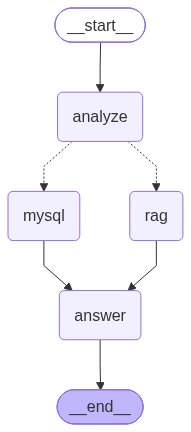

In [79]:
from IPython.display import Image, display

display(Image(hybrid_agent.get_graph().draw_mermaid_png()))

In [81]:
result = hybrid_agent.invoke({
  'question' : "이순신 학생의 수강과목을 알려주세요"
})

print(result.get('datasource'))
print(result.get('final_answer'))

--- hybrid router ---
--- MySQL DB 검색 ---
--- hybrid 최종 답변 ---


InvalidUpdateError: Must write to at least one of ['question', 'datasource', 'context', 'final_answer']